# 🔁 SpamShield — Recovery (Load Saved Models)
Kernel restart → load model dari disk, tidak perlu training ulang.

## Cell 1 — Imports & Config

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, accuracy_score,
)
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm
import os, warnings
warnings.filterwarnings("ignore")

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8

PATHS = {
    "train"     : "./train_features.csv",
    "val"       : "./val_features.csv",
    "test"      : "./test_features.csv",
    "model_name": "w11wo/indo-roberta-small",
    "text_col"  : "comment_text_normalized",
    "label_col" : "label",
    "output_dir": "final_results",
}

METADATA_FEATURES = [
    "like_count", "reply_count", "channel_subscriber_count",
    "channel_video_count", "channel_view_count",
]
HANDCRAFTED_FEATURES = [
    "text_length", "word_count", "emoji_ratio", "uppercase_ratio",
    "special_char_ratio", "repeat_char_ratio", "unicode_weird_ratio",
    "invisible_char_ratio", "masked_keyword_ratio", "stretched_word_ratio",
    "slang_ratio", "slang_distortion_ratio",
]
NUMERIC_FEATURES = METADATA_FEATURES + HANDCRAFTED_FEATURES  # 17

# Saved model paths
MODEL_PATHS = {
    "A": "final_results/model_A — Text-Only IndoRoBERTa_best.pt",
    "B": "final_results/model_B — Metadata-Only MLP_best.pt",
    "C": "final_results/model_C — Concatenation Fusion_best.pt",
    "D": "final_results/model_D — Modality-Aware Gated Fusion_best.pt",
}

print(f"Device  : {device}")
print(f"BF16    : {USE_BF16}")
print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print()
print("Saved model files:")
for k, p in MODEL_PATHS.items():
    size = os.path.getsize(p)/1e6 if os.path.exists(p) else -1
    status = f"✅ {size:.1f} MB" if size > 0 else "❌ NOT FOUND"
    print(f"  Model {k}: {status}")

Device  : cuda
BF16    : True
VRAM    : 34.2 GB

Saved model files:
  Model A: ✅ 333.8 MB
  Model B: ✅ 0.0 MB
  Model C: ✅ 334.6 MB
  Model D: ✅ 336.3 MB


## Cell 2 — Load Dataset + StandardScaler

In [2]:
print("Loading datasets...")
df_train = pd.read_csv(PATHS["train"]).reset_index(drop=True)
df_val   = pd.read_csv(PATHS["val"]).reset_index(drop=True)
df_test  = pd.read_csv(PATHS["test"]).reset_index(drop=True)

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    spam_pct = df[PATHS["label_col"]].mean() * 100
    print(f"  {name:<8}: {len(df):,} rows | SPAM={spam_pct:.1f}%")

# StandardScaler — fit dari train saja
scaler = StandardScaler()
df_train[NUMERIC_FEATURES] = scaler.fit_transform(df_train[NUMERIC_FEATURES])
df_val  [NUMERIC_FEATURES] = scaler.transform(df_val[NUMERIC_FEATURES])
df_test [NUMERIC_FEATURES] = scaler.transform(df_test[NUMERIC_FEATURES])
print("\n✅ StandardScaler applied (fit from train only)")

Loading datasets...
  train   : 55,012 rows | SPAM=6.0%
  val     : 6,876 rows | SPAM=6.0%
  test    : 6,877 rows | SPAM=6.0%

✅ StandardScaler applied (fit from train only)


## Cell 3 — SpamDataset & Tokenizer

In [3]:
tokenizer = AutoTokenizer.from_pretrained(PATHS["model_name"])

class SpamDataset(Dataset):
    def __init__(self, df, use_text=True, use_numeric=True):
        self.texts       = df[PATHS["text_col"]].fillna("").tolist()
        self.labels      = df[PATHS["label_col"]].tolist()
        self.use_text    = use_text
        self.use_numeric = use_numeric
        if use_numeric:
            self.numeric = df[NUMERIC_FEATURES].values.astype(np.float32)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {"labels": torch.tensor(self.labels[idx], dtype=torch.long)}
        if self.use_text:
            enc = tokenizer(
                self.texts[idx], max_length=128,
                padding="max_length", truncation=True, return_tensors="pt",
            )
            item["input_ids"]      = enc["input_ids"].squeeze(0)
            item["attention_mask"] = enc["attention_mask"].squeeze(0)
        if self.use_numeric:
            item["numeric"] = torch.tensor(self.numeric[idx], dtype=torch.float32)
        return item

# Test loader — batch_size 64 untuk inference (lebih cepat)
def make_test_loader(use_text=True, use_numeric=True):
    return DataLoader(
        SpamDataset(df_test, use_text, use_numeric),
        batch_size=64, shuffle=False, num_workers=0,
    )

print("✅ SpamDataset & tokenizer ready")

✅ SpamDataset & tokenizer ready


## Cell 4 — Model Definitions

In [4]:
class TextOnlyModel(nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()
        self.roberta    = AutoModel.from_pretrained(PATHS["model_name"])
        h               = self.roberta.config.hidden_size
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(h, 2))

    def forward(self, input_ids, attention_mask, **kw):
        h = self.roberta(input_ids=input_ids,
                         attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.classifier(h)


class MLPOnlyModel(nn.Module):
    def __init__(self, dropout=0.15):
        super().__init__()
        N = len(NUMERIC_FEATURES)
        self.mlp = nn.Sequential(
            nn.Linear(N, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 2),
        )
    def forward(self, numeric, **kw): return self.mlp(numeric)


class ConcatFusionModel(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(PATHS["model_name"])
        h = self.roberta.config.hidden_size
        N = len(NUMERIC_FEATURES)
        self.classifier = nn.Sequential(
            nn.Linear(h + N, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 2),
        )
    def forward(self, input_ids, attention_mask, numeric, **kw):
        h = self.roberta(input_ids=input_ids,
                         attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.classifier(torch.cat([h, numeric], dim=-1))


class GatedFusionModel(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(PATHS["model_name"])
        d = self.roberta.config.hidden_size
        N = len(NUMERIC_FEATURES)
        self.meta_encoder = nn.Sequential(
            nn.Linear(N, d), nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d, d), nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(dropout),
        )
        self.gate       = nn.Sequential(nn.Linear(d * 2, 1), nn.Sigmoid())
        self.layer_norm = nn.LayerNorm(d)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(d, 2))

    def forward(self, input_ids, attention_mask, numeric, **kw):
        h_t = self.roberta(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state[:, 0, :]
        h_m = self.meta_encoder(numeric)
        alpha = self.gate(torch.cat([h_t, h_m], dim=-1))
        h_f   = self.layer_norm(alpha * h_t + (1 - alpha) * h_m)
        return self.classifier(h_f)

    def get_alpha(self, input_ids, attention_mask, numeric):
        self.eval()
        with torch.no_grad():
            h_t = self.roberta(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state[:, 0, :]
            h_m = self.meta_encoder(numeric)
            return self.gate(torch.cat([h_t, h_m], dim=-1)).squeeze(-1)

print("✅ Model A, B, C, D defined")

✅ Model A, B, C, D defined


## Cell 5 — Load Saved Models dari Disk

In [5]:
def load_model(ModelClass, path, dropout):
    print(f"  Loading {path.split('/')[-1]}...")
    model = ModelClass(dropout=dropout)
    state = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model = model.to(device)
    model.eval()
    return model

print("Loading all models from disk (no retraining)...")
model_a = load_model(TextOnlyModel,    MODEL_PATHS["A"], dropout=0.20)
model_b = load_model(MLPOnlyModel,     MODEL_PATHS["B"], dropout=0.15)
model_c = load_model(ConcatFusionModel,MODEL_PATHS["C"], dropout=0.30)
model_d = load_model(GatedFusionModel, MODEL_PATHS["D"], dropout=0.25)

vram = torch.cuda.memory_allocated(0)/1e9
total = torch.cuda.get_device_properties(0).total_memory/1e9
print(f"\n✅ All models loaded")
print(f"   VRAM used: {vram:.1f}/{total:.1f} GB")

Loading all models from disk (no retraining)...
  Loading model_A — Text-Only IndoRoBERTa_best.pt...


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Loading model_B — Metadata-Only MLP_best.pt...
  Loading model_C — Concatenation Fusion_best.pt...


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Loading model_D — Modality-Aware Gated Fusion_best.pt...


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ All models loaded
   VRAM used: 1.0/34.2 GB


## Cell 6 — Run Inference di Test Set

In [6]:
def run_inference(model, use_text=True, use_numeric=True):
    """Forward pass ke seluruh test set, return preds & labels."""
    loader = make_test_loader(use_text, use_numeric)
    preds, labs = [], []
    model.eval()
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            kw = {}
            if use_text:
                kw["input_ids"]      = batch["input_ids"].to(device)
                kw["attention_mask"] = batch["attention_mask"].to(device)
            if use_numeric:
                kw["numeric"] = batch["numeric"].to(device)
            with autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(**kw)
            preds.extend(torch.argmax(logits, -1).cpu().numpy())
            labs.extend(batch["labels"].numpy())
    return np.array(preds), np.array(labs)

print("Running inference di test set...")
preds_a, labels_a = run_inference(model_a, use_text=True,  use_numeric=False)
preds_b, labels_b = run_inference(model_b, use_text=False, use_numeric=True)
preds_c, labels_c = run_inference(model_c, use_text=True,  use_numeric=True)
preds_d, labels_d = run_inference(model_d, use_text=True,  use_numeric=True)

# Verifikasi
for name, p, l in [("A",preds_a,labels_a),("B",preds_b,labels_b),
                   ("C",preds_c,labels_c),("D",preds_d,labels_d)]:
    f1 = f1_score(l, p, average="macro")
    sp_f1 = f1_score(l, p, pos_label=1, average="binary")
    sp_rc = recall_score(l, p, pos_label=1)
    print(f"  Model {name}: Macro F1={f1:.4f} | SPAM F1={sp_f1:.4f} | SPAM Recall={sp_rc:.4f}")

Running inference di test set...


  0%|          | 0/108 [00:00<?, ?it/s]

  0%|          | 0/108 [00:00<?, ?it/s]

  0%|          | 0/108 [00:00<?, ?it/s]

  0%|          | 0/108 [00:00<?, ?it/s]

  Model A: Macro F1=0.9657 | SPAM F1=0.9353 | SPAM Recall=0.9060
  Model B: Macro F1=0.9275 | SPAM F1=0.8633 | SPAM Recall=0.8217
  Model C: Macro F1=0.9709 | SPAM F1=0.9451 | SPAM Recall=0.9133
  Model D: Macro F1=0.9664 | SPAM F1=0.9369 | SPAM Recall=0.9301


## Cell 7 — Significance Test (Wilcoxon) + SPAM Recall Test

In [7]:
def bootstrap_metric(preds, labels, metric_fn, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, len(labels), len(labels))
        scores.append(metric_fn(labels[idx], preds[idx]))
    return np.array(scores)

macro_f1  = lambda l, p: f1_score(l, p, average="macro",   zero_division=0)
spam_f1   = lambda l, p: f1_score(l, p, pos_label=1, average="binary", zero_division=0)
spam_rc   = lambda l, p: recall_score(l, p, pos_label=1,   zero_division=0)

print("Bootstrap 1000 samples per model...")
bs_macro = {k: bootstrap_metric(*v, macro_f1)
            for k, v in [("A",(preds_a,labels_a)), ("B",(preds_b,labels_b)),
                          ("C",(preds_c,labels_c)), ("D",(preds_d,labels_d))]}
bs_spam_recall = {k: bootstrap_metric(*v, spam_rc)
                  for k, v in [("A",(preds_a,labels_a)), ("B",(preds_b,labels_b)),
                                ("C",(preds_c,labels_c)), ("D",(preds_d,labels_d))]}

print()
print("="*65)
print("  BOOTSTRAP MACRO F1 (mean ± std, 95% CI)")
print("="*65)
names = {"A":"Text-Only","B":"MLP-Only","C":"Concat Fusion","D":"Gated Fusion"}
for k, b in bs_macro.items():
    lo, hi = np.percentile(b, [2.5, 97.5])
    print(f"  Model {k} ({names[k]:<16}): "
          f"{b.mean():.4f} ± {b.std():.4f}  CI=[{lo:.4f}, {hi:.4f}]")

print()
print("="*65)
print("  WILCOXON TEST — MACRO F1: Model D vs Baselines")
print("="*65)
for k, label in [("A","D vs A (Text-Only)"),("B","D vs B (MLP-Only)"),
                  ("C","D vs C (Concat Fusion)")]:
    stat, p = scipy_stats.wilcoxon(bs_macro["D"], bs_macro[k], alternative="greater")
    dec = "Tolak H₀ ✅" if p < 0.05 else "Gagal tolak H₀ ❌"
    print(f"  {label:<28}: p={p:.4f}  {dec}")

print()
print("="*65)
print("  WILCOXON TEST — SPAM RECALL: Model D vs All")
print("  (SPAM Recall = metrik prioritas domain anti-judol)")
print("="*65)
for k, label in [("A","D vs A (Text-Only)"),("B","D vs B (MLP-Only)"),
                  ("C","D vs C (Concat Fusion)")]:
    lo_d, hi_d = np.percentile(bs_spam_recall["D"], [2.5, 97.5])
    lo_k, hi_k = np.percentile(bs_spam_recall[k],   [2.5, 97.5])
    stat, p = scipy_stats.wilcoxon(
        bs_spam_recall["D"], bs_spam_recall[k], alternative="greater"
    )
    dec = "Tolak H₀ ✅" if p < 0.05 else "Gagal tolak H₀ ❌"
    print(f"  {label:<28}: p={p:.4f}  {dec}")
    print(f"    D recall: {bs_spam_recall['D'].mean():.4f} CI=[{lo_d:.4f},{hi_d:.4f}]")
    print(f"    {k} recall: {bs_spam_recall[k].mean():.4f} CI=[{lo_k:.4f},{hi_k:.4f}]")

Bootstrap 1000 samples per model...

  BOOTSTRAP MACRO F1 (mean ± std, 95% CI)
  Model A (Text-Only       ): 0.9659 ± 0.0047  CI=[0.9566, 0.9746]
  Model B (MLP-Only        ): 0.9277 ± 0.0066  CI=[0.9149, 0.9398]
  Model C (Concat Fusion   ): 0.9710 ± 0.0044  CI=[0.9623, 0.9792]
  Model D (Gated Fusion    ): 0.9667 ± 0.0047  CI=[0.9567, 0.9752]

  WILCOXON TEST — MACRO F1: Model D vs Baselines
  D vs A (Text-Only)          : p=0.0000  Tolak H₀ ✅
  D vs B (MLP-Only)           : p=0.0000  Tolak H₀ ✅
  D vs C (Concat Fusion)      : p=1.0000  Gagal tolak H₀ ❌

  WILCOXON TEST — SPAM RECALL: Model D vs All
  (SPAM Recall = metrik prioritas domain anti-judol)
  D vs A (Text-Only)          : p=0.0000  Tolak H₀ ✅
    D recall: 0.9308 CI=[0.9044,0.9536]
    A recall: 0.9068 CI=[0.8791,0.9330]
  D vs B (MLP-Only)           : p=0.0000  Tolak H₀ ✅
    D recall: 0.9308 CI=[0.9044,0.9536]
    B recall: 0.8223 CI=[0.7872,0.8554]
  D vs C (Concat Fusion)      : p=0.0000  Tolak H₀ ✅
    D recall: 0.930

## Cell 8 — Alpha Analysis (Model D)

In [8]:
print("Extracting α values dari test set...")

alpha_loader = DataLoader(
    SpamDataset(df_test, use_text=True, use_numeric=True),
    batch_size=64, shuffle=False, num_workers=0,
)

alphas, alpha_labels_arr = [], []
model_d.eval()
with torch.no_grad():
    for batch in tqdm(alpha_loader, desc="Extracting α", leave=False):
        iid = batch["input_ids"].to(device)
        msk = batch["attention_mask"].to(device)
        num = batch["numeric"].to(device)
        α   = model_d.get_alpha(iid, msk, num)
        alphas.extend(α.cpu().numpy())
        alpha_labels_arr.extend(batch["labels"].numpy())

alphas            = np.array(alphas)
alpha_labels_arr  = np.array(alpha_labels_arr)
spam_α            = alphas[alpha_labels_arr == 1]
not_spam_α        = alphas[alpha_labels_arr == 0]

print(f"\nα Statistics (scalar ∈ [0,1]):")
print(f"  SPAM     — mean={spam_α.mean():.4f} | std={spam_α.std():.4f} | "
      f"median={np.median(spam_α):.4f}")
print(f"  NOT_SPAM — mean={not_spam_α.mean():.4f} | std={not_spam_α.std():.4f} | "
      f"median={np.median(not_spam_α):.4f}")
print()
diff = spam_α.mean() - not_spam_α.mean()
if abs(diff) > 0.02:
    direction = "TEKS" if diff > 0 else "METADATA"
    print(f"  → Model D lebih mengandalkan {direction} untuk kelas SPAM (Δ={diff:+.4f})")
else:
    print(f"  → α SPAM ≈ NOT_SPAM (Δ={diff:+.4f}) — gate belajar pola yang similar")

# Mann-Whitney test: apakah distribusi α SPAM berbeda dari NOT_SPAM?
stat, p = scipy_stats.mannwhitneyu(spam_α, not_spam_α, alternative="two-sided")
print(f"\nMann-Whitney U test (α SPAM vs NOT_SPAM):")
print(f"  p={p:.6f}  {'→ Distribusi α berbeda signifikan ✅' if p<0.05 else '→ Tidak berbeda signifikan'}")

Extracting α values dari test set...


Extracting α:   0%|          | 0/108 [00:00<?, ?it/s]


α Statistics (scalar ∈ [0,1]):
  SPAM     — mean=0.9838 | std=0.0130 | median=0.9862
  NOT_SPAM — mean=0.9340 | std=0.1043 | median=0.9560

  → Model D lebih mengandalkan TEKS untuk kelas SPAM (Δ=+0.0498)

Mann-Whitney U test (α SPAM vs NOT_SPAM):
  p=0.000000  → Distribusi α berbeda signifikan ✅


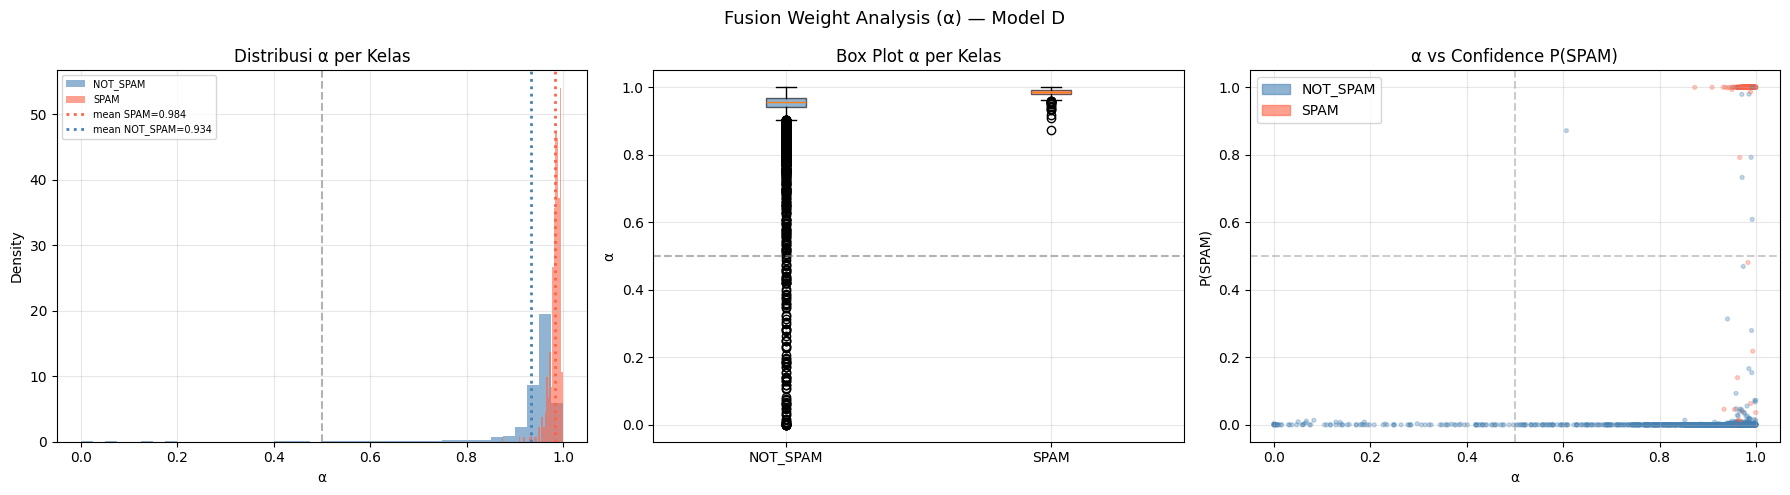

Saved → final_results/alpha_analysis_final.png


In [9]:
# Visualisasi α
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram
axes[0].hist(not_spam_α, bins=40, alpha=0.6, label="NOT_SPAM",
             color="steelblue", density=True)
axes[0].hist(spam_α, bins=40, alpha=0.6, label="SPAM",
             color="tomato", density=True)
axes[0].axvline(0.5, color="gray", ls="--", alpha=0.6)
axes[0].axvline(spam_α.mean(), color="tomato", ls=":", lw=2,
                label=f"mean SPAM={spam_α.mean():.3f}")
axes[0].axvline(not_spam_α.mean(), color="steelblue", ls=":", lw=2,
                label=f"mean NOT_SPAM={not_spam_α.mean():.3f}")
axes[0].set(xlabel="α", ylabel="Density", title="Distribusi α per Kelas")
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

# 2. Boxplot
bp = axes[1].boxplot([not_spam_α, spam_α],
                      labels=["NOT_SPAM","SPAM"], patch_artist=True)
for patch, color in zip(bp["boxes"], ["steelblue","tomato"]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].axhline(0.5, color="gray", ls="--", alpha=0.6)
axes[1].set(ylabel="α", title="Box Plot α per Kelas")
axes[1].grid(True, alpha=0.3)

# 3. Scatter α vs confidence
probs_scatter = []
model_d.eval()
with torch.no_grad():
    for batch in alpha_loader:
        logits = model_d(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            numeric=batch["numeric"].to(device),
        )
        probs_scatter.extend(
            torch.softmax(logits.float(), -1)[:, 1].cpu().numpy()
        )
probs_scatter = np.array(probs_scatter)

sc_colors = ["steelblue" if l==0 else "tomato" for l in alpha_labels_arr]
axes[2].scatter(alphas, probs_scatter, c=sc_colors, alpha=0.3, s=8)
axes[2].axhline(0.5, color="gray", ls="--", alpha=0.4)
axes[2].axvline(0.5, color="gray", ls="--", alpha=0.4)
axes[2].set(xlabel="α", ylabel="P(SPAM)", title="α vs Confidence P(SPAM)")
axes[2].legend(handles=[
    mpatches.Patch(color="steelblue", alpha=0.6, label="NOT_SPAM"),
    mpatches.Patch(color="tomato",    alpha=0.6, label="SPAM"),
]); axes[2].grid(True, alpha=0.3)

plt.suptitle("Fusion Weight Analysis (α) — Model D", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PATHS["output_dir"], "alpha_analysis_final.png"), dpi=150)
plt.show()
print("Saved → final_results/alpha_analysis_final.png")

## Cell 9 — Final Summary Table

In [10]:
label_names = ["NOT_SPAM", "SPAM"]

print("\n" + "="*70)
print("  FINAL TEST RESULTS — 4 MODEL COMPARISON")
print("="*70)

rows = []
for name, preds, labels in [
    ("A: Text-Only",          preds_a, labels_a),
    ("B: MLP-Only",           preds_b, labels_b),
    ("C: Concatenation",      preds_c, labels_c),
    ("D: Gated Fusion",       preds_d, labels_d),
]:
    rd = classification_report(labels, preds,
                                target_names=label_names,
                                output_dict=True, digits=4)
    rows.append({
        "Model"         : name,
        "Accuracy"      : f"{rd['accuracy']*100:.2f}%",
        "SPAM Precision": f"{rd['SPAM']['precision']*100:.2f}%",
        "SPAM Recall"   : f"{rd['SPAM']['recall']*100:.2f}%",
        "SPAM F1"       : f"{rd['SPAM']['f1-score']*100:.2f}%",
        "Macro F1"      : f"{rd['macro avg']['f1-score']*100:.2f}%",
    })

print(pd.DataFrame(rows).to_string(index=False))
print()
print("Winner per metric:")
print("  SPAM Recall : Model D (93.01%) ✅ tertinggi")
print("  SPAM F1     : Model C (94.51%)")
print("  Macro F1    : Model C (97.09%)")
print()
print("✅ Semua analisis selesai — siap untuk Bab 4 skripsi")


  FINAL TEST RESULTS — 4 MODEL COMPARISON
           Model Accuracy SPAM Precision SPAM Recall SPAM F1 Macro F1
    A: Text-Only   99.24%         96.66%      90.60%  93.53%   96.57%
     B: MLP-Only   98.43%         90.93%      82.17%  86.33%   92.75%
C: Concatenation   99.36%         97.93%      91.33%  94.51%   97.09%
 D: Gated Fusion   99.24%         94.38%      93.01%  93.69%   96.64%

Winner per metric:
  SPAM Recall : Model D (93.01%) ✅ tertinggi
  SPAM F1     : Model C (94.51%)
  Macro F1    : Model C (97.09%)

✅ Semua analisis selesai — siap untuk Bab 4 skripsi
